## Задача №1 
### Непрерывная марковская цепь
**Параметры варианта:** $N=120$, $G=4$.

Система содержит устройства типов **A** и **B** с интенсивностями отказов $\lambda_A$, $\lambda_B$. Для работоспособности нужно: 
- хотя бы **1** устройство типа **A**;
- хотя бы **$N_B$** устройств типа **B**.

Есть резервы: $R_A$, $R_B$. В нормальном состоянии одновременно включены $N_A$ устройств типа **A**.

Далее: граф состояний, матрица интенсивностей $Q$, уравнения Колмогорова, численное решение, графики вероятностей и надёжности, $\mathbb{E}[T]$, затем имитация CTMC (100 прогонов).

*Здесь и далее под CTMC - непрерывные марковские процессы, т.е. процессы, время между переходами в которых непрерывно.*


### Параметры системы
По условиям (для $N=120$, $G=4$):

$$
\lambda_A = G + (N \bmod 3)=4,\quad
\lambda_B = G + (N \bmod 5)=4
$$
$$
N_A = 2 + (G \bmod 2)=2,\quad
N_B = 1 + (N \bmod 2)=1
$$
$$
R_A = 1 + (G \bmod 2)=1,\quad
R_B = 2 - (G \bmod 2)=2
$$
Итого устройств: $A_{\text{tot}} = N_A+R_A=3$, $B_{\text{tot}} = N_B+R_B=3$.

### Модель (CTMC)
Состояние задаём парой $(i,j)$, где:
- $i$ — число отказавших устройств типа **A** (от 0 до $A_{\text{tot}}$);
- $j$ — число отказавших устройств типа **B** (от 0 до $B_{\text{tot}}$).

Считаем, что резерв включается **мгновенно**, и число одновременно работающих устройств в состоянии $(i,j)$:

$$
A_{\text{on}}(i)=\min\bigl(N_A,\;A_{\text{tot}}-i\bigr),\quad
B_{\text{on}}(j)=\min\bigl(N_B,\;B_{\text{tot}}-j\bigr)
$$

Тогда интенсивности отказов (переходов) из $(i,j)$:
- $(i,j)\to(i+1,j)$ с интенсивностью $A_{\text{on}}(i)\,\lambda_A$;
- $(i,j)\to(i,j+1)$ с интенсивностью $B_{\text{on}}(j)\,\lambda_B$.

**Поглощающие (неработоспособные) состояния:** если $A_{\text{tot}}-i<1$ или $B_{\text{tot}}-j<N_B$.
Для наших чисел это просто $i=3$ или $j=3$.


In [25]:
import math
import numpy as np

N = 120
G = 4

lambda_A = G + (N % 3)
lambda_B = G + (N % 5)
NA = 2 + (G % 2)
NB = 1 + (N % 2)
RA = 1 + (G % 2)
RB = 2 - (G % 2)

A_tot = NA + RA
B_tot = NB + RB

params = {
    "N": N,
    "G": G,
    "lambda_A": lambda_A,
    "lambda_B": lambda_B,
    "NA": NA,
    "NB": NB,
    "RA": RA,
    "RB": RB,
    "A_tot": A_tot,
    "B_tot": B_tot,
}
params

{'N': 120,
 'G': 4,
 'lambda_A': 4,
 'lambda_B': 4,
 'NA': 2,
 'NB': 1,
 'RA': 1,
 'RB': 2,
 'A_tot': 3,
 'B_tot': 3}

In [26]:
from dataclasses import dataclass
from typing import Dict, List, Tuple

State = Tuple[int, int]  # (i, j)


def A_on(i: int) -> int:
    return min(NA, A_tot - i)


def B_on(j: int) -> int:
    return min(NB, B_tot - j)


def is_absorbing(s: State) -> bool:
    i, j = s
    return (A_tot - i) < 1 or (B_tot - j) < NB


all_states: List[State] = [(i, j) for i in range(A_tot + 1) for j in range(B_tot + 1)]
transient_states: List[State] = [s for s in all_states if not is_absorbing(s)]
absorbing_states: List[State] = [s for s in all_states if is_absorbing(s)]

len(all_states), len(transient_states), len(absorbing_states), transient_states[:5], absorbing_states[:5]

(16,
 9,
 7,
 [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)],
 [(0, 3), (1, 3), (2, 3), (3, 0), (3, 1)])

### 1) Граф состояний
Ниже строим ориентированный граф состояний $(i,j)$ с дугами в соседние состояния при отказе **A** или **B**.
Поглощающие состояния (отказ системы) выделим отдельным цветом.


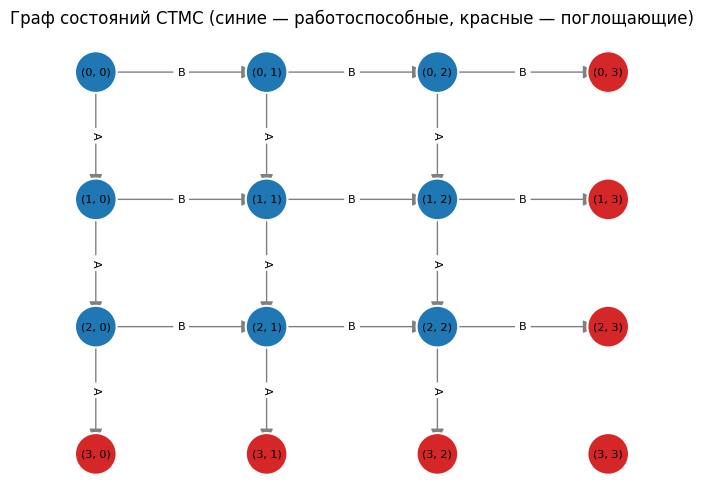

In [27]:
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Tuple

State = Tuple[int, int]

def build_graph(states: List[State]):
    Gnx = nx.DiGraph()
    for s in states:
        Gnx.add_node(s)

    for (i, j) in states:
        if i < A_tot:
            Gnx.add_edge((i, j), (i + 1, j), label="A")
        if j < B_tot:
            Gnx.add_edge((i, j), (i, j + 1), label="B")
    return Gnx


Gnx = build_graph(all_states)

pos = { (i,j): (j, -i) for (i,j) in all_states }  # сетка

plt.figure(figsize=(8, 6))
node_colors = ["#d62728" if is_absorbing(s) else "#1f77b4" for s in Gnx.nodes()]

nx.draw_networkx_nodes(
    Gnx,
    pos=pos,
    node_size=900,
    node_color=node_colors,
    edgecolors="white",
    linewidths=1.5,
)

nx.draw_networkx_labels(
    Gnx,
    pos=pos,
    font_size=8,
)

# Фильтрация рёбер: исключаем исходящие из поглощающих состояний
edges_to_draw = [(u, v) for u, v in Gnx.edges() if not is_absorbing(u)]

nx.draw_networkx_edges(
    Gnx,
    pos=pos,
    edgelist=edges_to_draw,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
    edge_color="gray",
)

edge_labels = nx.get_edge_attributes(Gnx, "label")
edge_labels_filtered = {k: v for k, v in edge_labels.items() if k in edges_to_draw}
nx.draw_networkx_edge_labels(
    Gnx,
    pos=pos,
    edge_labels=edge_labels_filtered,
    font_size=8,
)

plt.title("Граф состояний CTMC (синие — работоспособные, красные — поглощающие)")
plt.axis("off")
plt.show()

### 2) Матрица интенсивностей переходов $Q$
Для CTMC матрица $Q$ (generator) задаётся так:
- для $k\neq \ell$ элемент $q_{k\ell}$ — интенсивность перехода из состояния $k$ в состояние $\ell$;
- диагональ $q_{kk} = -\sum_{\ell\neq k} q_{k\ell}$;
- в поглощающих состояниях (отказ системы) строка обычно нулевая (выходов нет).

Ниже строим $Q$ в порядке состояний `all_states`.


In [28]:
import pandas as pd

state_to_idx: Dict[State, int] = {s: k for k, s in enumerate(all_states)}
idx_to_state: Dict[int, State] = {k: s for s, k in state_to_idx.items()}


def build_Q() -> np.ndarray:
    n = len(all_states)
    Q = np.zeros((n, n), dtype=float)

    for s in all_states:
        i, j = s
        k = state_to_idx[s]

        if is_absorbing(s):
            continue  # поглощающее: строка нулевая

        rate_out = 0.0

        # отказ A: (i,j) -> (i+1,j)
        if i < A_tot:
            s2 = (i + 1, j)
            r = A_on(i) * lambda_A
            Q[k, state_to_idx[s2]] += r
            rate_out += r

        # отказ B: (i,j) -> (i,j+1)
        if j < B_tot:
            s2 = (i, j + 1)
            r = B_on(j) * lambda_B
            Q[k, state_to_idx[s2]] += r
            rate_out += r

        Q[k, k] = -rate_out

    return Q


Q = build_Q()

labels = [str(s) for s in all_states]
Q_df = pd.DataFrame(Q, index=labels, columns=labels)
Q_df

,"(0, 0)","(0, 1)","(0, 2)","(0, 3)","(1, 0)","(1, 1)","(1, 2)","(1, 3)","(2, 0)","(2, 1)","(2, 2)","(2, 3)","(3, 0)","(3, 1)","(3, 2)","(3, 3)"
"(0, 0)",-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, 1)",0.0,-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, 2)",0.0,0.0,-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, 3)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 0)",0.0,0.0,0.0,0.0,-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 1)",0.0,0.0,0.0,0.0,0.0,-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 2)",0.0,0.0,0.0,0.0,0.0,0.0,-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0
"(1, 3)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(2, 0)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-8.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0
"(2, 1)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-8.0,4.0,0.0,0.0,4.0,0.0,0.0


In [29]:
# Быстрая проверка свойств генератора: суммы строк <= 0, диагональ <= 0
row_sums = Q.sum(axis=1)
min_diag = np.min(np.diag(Q))
max_offdiag_negative = np.max(Q - np.diag(np.diag(Q)))
row_sums[:5], float(min_diag), float(max_offdiag_negative)

(array([0., 0., 0., 0., 0.]), -12.0, 8.0)

### 3) Дифференциальные уравнения Колмогорова (прямые)
Пусть $p_k(t)$ — вероятность состояния $k$ (в нашем случае $k\equiv (i,j)$).
Тогда система уравнений Колмогорова для вектора вероятностей $p(t)$ (строка) имеет вид:

$$
\frac{d}{dt}p(t)=p(t)Q.
$$

Покомпонентно для состояния $k$:

$$
\frac{dp_k(t)}{dt}=\sum_{\ell} p_{\ell}(t)\,q_{\ell k}.
$$

Ниже автоматически выпишем уравнение для каждого состояния $(i,j)$ (в выбранном порядке `all_states`).


In [30]:
def kolmogorov_equation_for_state(target: State, tol: float = 1e-12) -> str:
    k = state_to_idx[target]
    terms = []

    # входящие потоки: p_l * q_{l,k}
    for l, s_l in enumerate(all_states):
        q_lk = Q[l, k]
        if abs(q_lk) > tol:
            terms.append((s_l, q_lk))

    # Сформируем строку вида: dp_(i,j)/dt = ...
    left = f"dp_{target}/dt"

    def fmt_coeff(x: float) -> str:
        # аккуратное форматирование 4.0 -> 4
        if abs(x - round(x)) < 1e-9:
            return str(int(round(x)))
        return f"{x:.6g}"

    rhs_parts = []
    for s_l, coeff in terms:
        sign = "+" if coeff >= 0 else "-"
        rhs_parts.append(f" {sign} {fmt_coeff(abs(coeff))}·p_{s_l}(t)")

    rhs = "".join(rhs_parts)
    if rhs.startswith(" +"):
        rhs = rhs[2:]
    return f"{left} = {rhs}"


eq_lines = [kolmogorov_equation_for_state(s) for s in all_states]
"\n".join(eq_lines)

'dp_(0, 0)/dt =  - 12·p_(0, 0)(t)\ndp_(0, 1)/dt =  4·p_(0, 0)(t) - 12·p_(0, 1)(t)\ndp_(0, 2)/dt =  4·p_(0, 1)(t) - 12·p_(0, 2)(t)\ndp_(0, 3)/dt =  4·p_(0, 2)(t)\ndp_(1, 0)/dt =  8·p_(0, 0)(t) - 12·p_(1, 0)(t)\ndp_(1, 1)/dt =  8·p_(0, 1)(t) + 4·p_(1, 0)(t) - 12·p_(1, 1)(t)\ndp_(1, 2)/dt =  8·p_(0, 2)(t) + 4·p_(1, 1)(t) - 12·p_(1, 2)(t)\ndp_(1, 3)/dt =  4·p_(1, 2)(t)\ndp_(2, 0)/dt =  8·p_(1, 0)(t) - 8·p_(2, 0)(t)\ndp_(2, 1)/dt =  8·p_(1, 1)(t) + 4·p_(2, 0)(t) - 8·p_(2, 1)(t)\ndp_(2, 2)/dt =  8·p_(1, 2)(t) + 4·p_(2, 1)(t) - 8·p_(2, 2)(t)\ndp_(2, 3)/dt =  4·p_(2, 2)(t)\ndp_(3, 0)/dt =  4·p_(2, 0)(t)\ndp_(3, 1)/dt =  4·p_(2, 1)(t)\ndp_(3, 2)/dt =  4·p_(2, 2)(t)\ndp_(3, 3)/dt = '

### 4) Численное решение системы (начальное состояние: все устройства исправны)
Начальное условие: $p_{(0,0)}(0)=1$, остальные $0$.

Численно решаем систему $p'(t)=p(t)Q$.
Чтобы не зависеть от наличия `scipy`, используем простую схему Рунге–Кутты 4-го порядка (RK4).


In [31]:
def rk4_integrate_pQ(Q: np.ndarray, p0: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    """Решаем p'(t)=p(t)Q, p — строковый вектор."""
    p = np.zeros((len(t_grid), len(p0)), dtype=float)
    p[0] = p0

    for n in range(len(t_grid) - 1):
        t = t_grid[n]
        h = t_grid[n + 1] - t
        y = p[n]

        f = lambda yy: yy @ Q

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y_next = y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

        # Численные погрешности: слегка подрезаем отрицательные значения
        y_next[y_next < 0] = 0.0
        s = y_next.sum()
        if s > 0:
            y_next = y_next / s

        p[n + 1] = y_next

    return p


# сетка времени (выбираем достаточно, чтобы надёжность заметно упала)
T_max = 2.0
n_steps = 800

t = np.linspace(0.0, T_max, n_steps + 1)

p0 = np.zeros(len(all_states), dtype=float)
p0[state_to_idx[(0, 0)]] = 1.0

P = rk4_integrate_pQ(Q, p0, t)
P.shape, float(P[0].sum()), float(P[-1].sum())

((801, 16), 1.0, 1.0)

### 5) Графики вероятностей состояний $p_{(i,j)}(t)$
Построим 16 графиков (сетка $4\times 4$) — по одному на каждое состояние $(i,j)$.


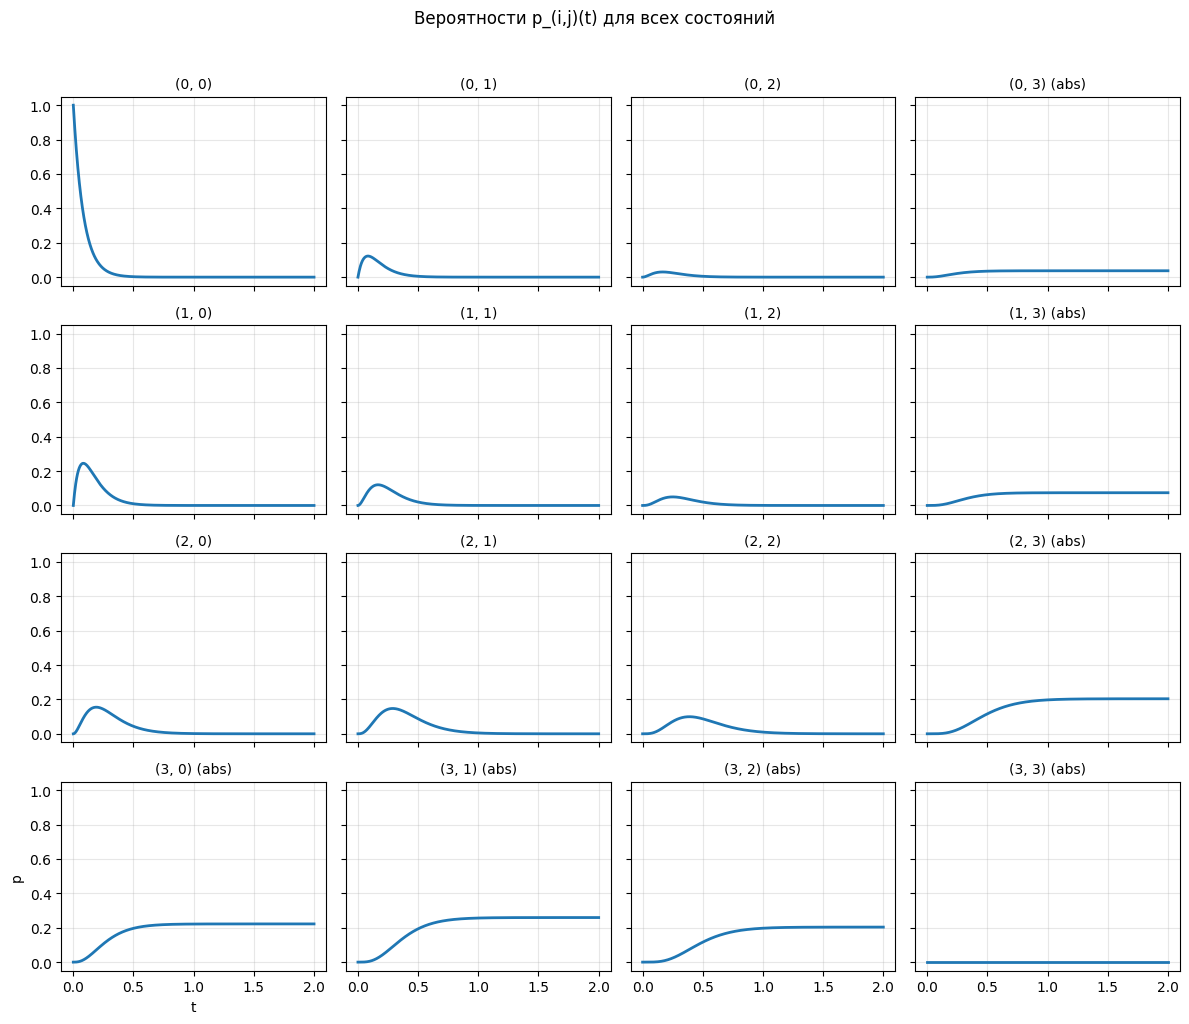

In [32]:
fig, axes = plt.subplots(A_tot + 1, B_tot + 1, figsize=(12, 10), sharex=True, sharey=True)

for i in range(A_tot + 1):
    for j in range(B_tot + 1):
        ax = axes[i, j]
        s = (i, j)
        k = state_to_idx[s]
        ax.plot(t, P[:, k], lw=2)
        ax.set_title(f"{s}" + (" (abs)" if is_absorbing(s) else ""), fontsize=10)
        ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("t")
axes[-1, 0].set_ylabel("p")
plt.suptitle("Вероятности p_(i,j)(t) для всех состояний", y=1.02)
plt.tight_layout()
plt.show()

### 6) Функция надёжности системы $R(t)$
Определим надёжность как вероятность того, что система **работоспособна** в момент $t$:

$$
R(t)=\sum_{s\in \mathcal{T}} p_s(t),
$$

где $\mathcal{T}$ — множество непоглощающих (работоспособных) состояний.


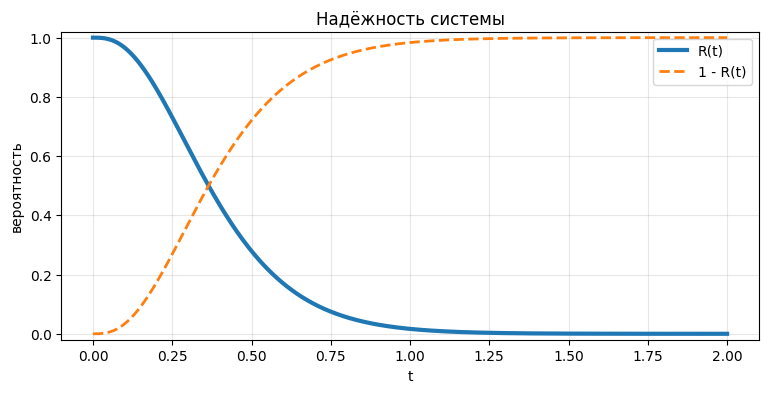

(1.0, 1.8426360557781635e-05)

In [33]:
transient_idx = np.array([state_to_idx[s] for s in transient_states], dtype=int)
absorbing_idx = np.array([state_to_idx[s] for s in absorbing_states], dtype=int)

R = P[:, transient_idx].sum(axis=1)
F = 1.0 - R

plt.figure(figsize=(9, 4))
plt.plot(t, R, lw=3, label="R(t)")
plt.plot(t, F, lw=2, ls="--", label="1 - R(t)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.xlabel("t")
plt.ylabel("вероятность")
plt.title("Надёжность системы")
plt.legend()
plt.show()

float(R[0]), float(R[-1])

### 7) Математическое ожидание времени безотказной работы $\mathbb{E}[T]$
Для поглощающей CTMC вектор матожиданий времени до поглощения $m$ для непоглощающих состояний решает систему:

$$
(-Q_{TT})\,m = \mathbf{1},
$$

где $Q_{TT}$ — подматрица $Q$, ограниченная на непоглощающие состояния.
Тогда искомое $\mathbb{E}[T]=m_{(0,0)}$.

(Дополнительно можно проверить, что $\mathbb{E}[T]=\int_0^{\infty} R(t)\,dt$.)


In [34]:
# Подматрица генератора для непоглощающих состояний
Q_TT = Q[np.ix_(transient_idx, transient_idx)]

# Решаем (-Q_TT) m = 1
b = np.ones(len(transient_idx), dtype=float)
m = np.linalg.solve(-Q_TT, b)

m0 = m[np.where(transient_idx == state_to_idx[(0, 0)])[0][0]]

# Численная проверка через интеграл R(t) (обрезанный по T_max)
MTTF_integral_trunc = np.trapezoid(R, t)

m0, MTTF_integral_trunc

(np.float64(0.40277777777777773), np.float64(0.4027752062940953))

### 8) Имитационное моделирование CTMC (100 прогонов)
Используем стандартную схему для непрерывной марковской цепи:
- в состоянии $s$ суммарная интенсивность выхода $\Lambda(s)=\sum_{s'} q_{s s'}$;
- время до следующего перехода $\Delta t \sim \text{Exp}(\Lambda(s))$;
- выбор следующего состояния пропорционально интенсивностям переходов.

Моделируем до поглощения (отказа системы) и получаем выборку времени безотказной работы.


In [35]:
rng = np.random.default_rng(42)


def simulate_time_to_failure(Q: np.ndarray, start: State = (0, 0), rng: np.random.Generator | None = None) -> float:
    if rng is None:
        rng = np.random.default_rng()

    s = start
    t_acc = 0.0

    while not is_absorbing(s):
        k = state_to_idx[s]
        rates = Q[k].copy()
        rates[k] = 0.0  # убираем диагональ
        rates[rates < 0] = 0.0
        lam = rates.sum()

        if lam <= 0:
            # на всякий случай: если нет выходов
            break

        dt = rng.exponential(1.0 / lam)
        t_acc += dt

        probs = rates / lam
        next_idx = rng.choice(len(all_states), p=probs)
        s = idx_to_state[next_idx]

    return t_acc


n_sim = 100
times = np.array([simulate_time_to_failure(Q, (0, 0), rng) for _ in range(n_sim)], dtype=float)

mean_sim = float(times.mean())
std_sim = float(times.std(ddof=1))

mean_sim, std_sim, m0

(0.392635289276946, 0.23933114657768062, np.float64(0.40277777777777773))

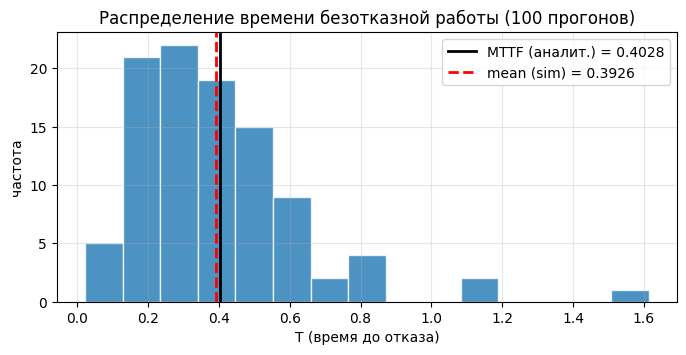

,count,mean,std,min,25%,50%,75%,max
T,100.0,0.392635,0.239331,0.022056,0.222887,0.371544,0.48246,1.613765


In [36]:
plt.figure(figsize=(8, 3.5))
plt.hist(times, bins=15, alpha=0.8, edgecolor="white")
plt.axvline(m0, color="black", lw=2, label=f"MTTF (аналит.) = {m0:.4f}")
plt.axvline(mean_sim, color="red", lw=2, ls="--", label=f"mean (sim) = {mean_sim:.4f}")
plt.grid(True, alpha=0.3)
plt.xlabel("T (время до отказа)")
plt.ylabel("частота")
plt.title("Распределение времени безотказной работы (100 прогонов)")
plt.legend()
plt.show()

pd.DataFrame({"T": times}).describe().T

### Итог (ключевые числа)
- $\lambda_A=4$, $\lambda_B=4$, $N_A=2$, $N_B=1$, $R_A=1$, $R_B=2$ ($A_{tot}=3$, $B_{tot}=3$).
- Поглощающие состояния (отказ): $i=3$ или $j=3$.
- $\mathbb{E}[T]$ (аналитически из $(-Q_{TT})m=\mathbf{1}$): выводится в ячейке выше.
- Имитация CTMC (100 прогонов): среднее и стандартное отклонение — также выведены выше.
